In [23]:
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt, xgboost as xgb
if os.path.basename(os.getcwd()) == 'notes': os.chdir('..')
print('工作目录:', os.getcwd())

工作目录: d:\github\prediction


In [ ]:
# ============================================================
# 从 NetCDF 读取 #0 站点 (1141A 普陀) → 80/15/5 分割 → 预处理 → 向量化特征构建
# 先分割再插值, 杜绝边界数据泄漏
# 参考: https://xgboost.readthedocs.io/en/stable/python/python_api.html
# ============================================================
import netCDF4 as nc

WEATHER = ['DEWP', 'HUMI', 'PRES', 'TEMP', 'Iws', 'precipitation', 'Iprec']
WEATHER_M6 = [f'{c}_m6' for c in WEATHER]
PM_LAGS = [1, 2, 3, 6, 12, 24]; MAX_LAG = 24
TIME_COLS = ['hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos']
CBWD_COLS = ['cbwd_cv', 'cbwd_SE', 'cbwd_NW', 'cbwd_SW', 'cbwd_NE']
ROLL_COLS = ['pm_r6m', 'pm_r6s', 'pm_r24m', 'pm_r24s']
TREND_COLS = ['pm_d_short', 'pm_d_long']
FEATURE_NAMES = (
    [f'pm_t-{l}' for l in PM_LAGS] + [f'{c}_t' for c in WEATHER] +
    WEATHER_M6 + TIME_COLS + CBWD_COLS + ROLL_COLS + TREND_COLS
)
N_FEAT = len(FEATURE_NAMES)  # 37

def load_station(nc_path, idx=0):
    """从 NetCDF 读取站点, 转为 DataFrame (变量映射: K→°C, Pa→hPa, m→mm)"""
    f = nc.Dataset(nc_path)
    t = f.variables['time'][:]
    dt = pd.Timestamp(f.variables['time'].units.split('since ')[1]) + pd.to_timedelta(t, unit='h')
    pm25 = f.variables['PM2.5'][:, idx]
    temp = f.variables['t2m'][:, idx] - 273.15
    dewp = f.variables['d2m'][:, idx] - 273.15
    pres = f.variables['sp'][:, idx] / 100.0
    tp = f.variables['tp'][:, idx] * 1000.0
    u, v = f.variables['u100'][:, idx], f.variables['v100'][:, idx]
    iws = np.sqrt(u**2 + v**2)
    wdir = np.degrees(np.arctan2(-u, -v)) % 360
    cbwd = np.where(iws < 0.5, 'cv', np.where(wdir < 90, 'NE',
           np.where(wdir < 180, 'SE', np.where(wdir < 270, 'SW', 'NW')))).astype('<U2')
    a, b = 17.625, 243.04
    humi = np.clip(100 * np.exp(a*dewp/(dewp+b+1e-10)) / np.exp(a*temp/(temp+b+1e-10)), 0, 100)
    f.close()
    df = pd.DataFrame({'PM_Jingan': pm25, 'PM_US Post': pm25, 'PM_Xuhui': pm25,
        'DEWP': dewp, 'HUMI': humi, 'PRES': pres, 'TEMP': temp,
        'cbwd': cbwd, 'Iws': iws, 'precipitation': tp, 'Iprec': np.cumsum(tp)}, index=dt)
    df.index.name = 'datetime'
    return df.resample('1h').first()

def preprocess(df):
    """单个子集独立预处理: pm_ave(log) → 气象插值 → 周期编码 → rolling"""
    d = df.copy()
    d['pm_ave'] = d[['PM_Jingan','PM_US Post','PM_Xuhui']].mean(axis=1)
    d['pm_ave'] = d['pm_ave'].interpolate(method='time', limit=168).ffill().bfill()
    d['pm_ave'] = np.log1p(d['pm_ave'])  # log 变换压缩高值
    d[WEATHER] = d[WEATHER].interpolate(method='time').ffill().bfill()
    h = d.index.hour.values.astype(float)
    d['hour_sin'] = np.sin(2*np.pi*h/24); d['hour_cos'] = np.cos(2*np.pi*h/24)
    m = d.index.month.values.astype(float)
    d['month_sin'] = np.sin(2*np.pi*m/12); d['month_cos'] = np.cos(2*np.pi*m/12)
    dw = d.index.dayofweek.values.astype(float)
    d['dow_sin'] = np.sin(2*np.pi*dw/7); d['dow_cos'] = np.cos(2*np.pi*dw/7)
    d['cbwd'] = d['cbwd'].ffill().bfill()
    d['cbwd'] = pd.Categorical(d['cbwd'], categories=['cv','SE','NW','SW','NE'])
    dummies = pd.get_dummies(d['cbwd'], prefix='cbwd').astype(float)
    d = pd.concat([d.drop('cbwd', axis=1), dummies], axis=1)
    d['pm_r6m']  = d['pm_ave'].rolling(6, min_periods=1).mean()
    d['pm_r6s']  = d['pm_ave'].rolling(6, min_periods=1).std().fillna(0)
    d['pm_r24m'] = d['pm_ave'].rolling(24, min_periods=1).mean()
    d['pm_r24s'] = d['pm_ave'].rolling(24, min_periods=1).std().fillna(0)
    for c in WEATHER: d[f'{c}_m6'] = d[c].rolling(6, min_periods=1).mean()
    return d

def build_features(df):
    """向量化构建特征: 用 shift() 保证物理时间对齐 (37 维)"""
    cols = {}
    for l in PM_LAGS: cols[f'pm_t-{l}'] = df['pm_ave'].shift(l)
    for c in WEATHER: cols[f'{c}_t'] = df[c]
    for c in WEATHER_M6: cols[c] = df[c]
    for c in TIME_COLS: cols[c] = df[c]
    for c in CBWD_COLS: cols[c] = df[c]
    for c in ROLL_COLS: cols[c] = df[c].shift(1)  # 最新观测 T-1 处
    cols['pm_d_short'] = df['pm_ave'].shift(1) - df['pm_ave'].shift(3)
    cols['pm_d_long']  = df['pm_ave'].shift(1) - df['pm_ave'].shift(24)
    feat = pd.DataFrame(cols, index=df.index).iloc[MAX_LAG:]
    y = df['pm_ave'].iloc[MAX_LAG:]
    return feat.values, y.values

# 加载 + 分割 + 预处理
df_raw = load_station('data3/dataset_yrd.nc', idx=0)
n = len(df_raw); n1 = int(n * 0.80); n2 = int(n * 0.95)
df_tr = preprocess(df_raw.iloc[:n1])
df_va = preprocess(df_raw.iloc[n1:n2])
df_te = preprocess(df_raw.iloc[n2:])
print(f'训练 {len(df_tr)} | 验证 {len(df_va)} | 测试 {len(df_te)}')

# 构建特征 (验证集带 MAX_LAG 行训练集上下文)
df_va_ctx = pd.concat([df_tr.iloc[-MAX_LAG:], df_va])
X_tr, y_tr = build_features(df_tr)
X_va, y_va = build_features(df_va_ctx)
print(f'特征维度: {N_FEAT} | 训练 {X_tr.shape} | 验证 {X_va.shape}')

# rolling std 下限 + 预测裁剪边界
STD_F6 = float(df_tr['pm_r6s'].quantile(0.25))
STD_F24 = float(df_tr['pm_r24s'].quantile(0.25))
CLIP_LO = float(np.percentile(df_tr['pm_ave'], 0.1))
CLIP_HI = float(np.percentile(df_tr['pm_ave'], 99.9))

print(f'Std 下限: {STD_F6:.4f} / {STD_F24:.4f} | 裁剪: [{np.expm1(CLIP_LO):.0f}, {np.expm1(CLIP_HI):.0f}] ug/m3')

训练 56102 | 验证 10519 | 测试 3507
特征维度: 37 | 训练 (56078, 37) | 验证 (10519, 37)
Std 下限: 0.0000 / 0.0000 | 裁剪: [1, 229] ug/m3


[0]	train-rmse:0.73390	eval-rmse:0.75406
[50]	train-rmse:0.58647	eval-rmse:0.61394
[100]	train-rmse:0.47440	eval-rmse:0.51039
[150]	train-rmse:0.39006	eval-rmse:0.43559
[200]	train-rmse:0.32738	eval-rmse:0.38358
[250]	train-rmse:0.28143	eval-rmse:0.34803
[300]	train-rmse:0.24811	eval-rmse:0.32496
[350]	train-rmse:0.22428	eval-rmse:0.31021
[400]	train-rmse:0.20726	eval-rmse:0.30116
[450]	train-rmse:0.19499	eval-rmse:0.29582
[500]	train-rmse:0.18597	eval-rmse:0.29285
[550]	train-rmse:0.17915	eval-rmse:0.29126
[600]	train-rmse:0.17379	eval-rmse:0.29043
[650]	train-rmse:0.16945	eval-rmse:0.29026
[700]	train-rmse:0.16588	eval-rmse:0.29048
[750]	train-rmse:0.16277	eval-rmse:0.29077
[754]	train-rmse:0.16253	eval-rmse:0.29080

最佳轮次: 655 | val RMSE (log): 0.2902


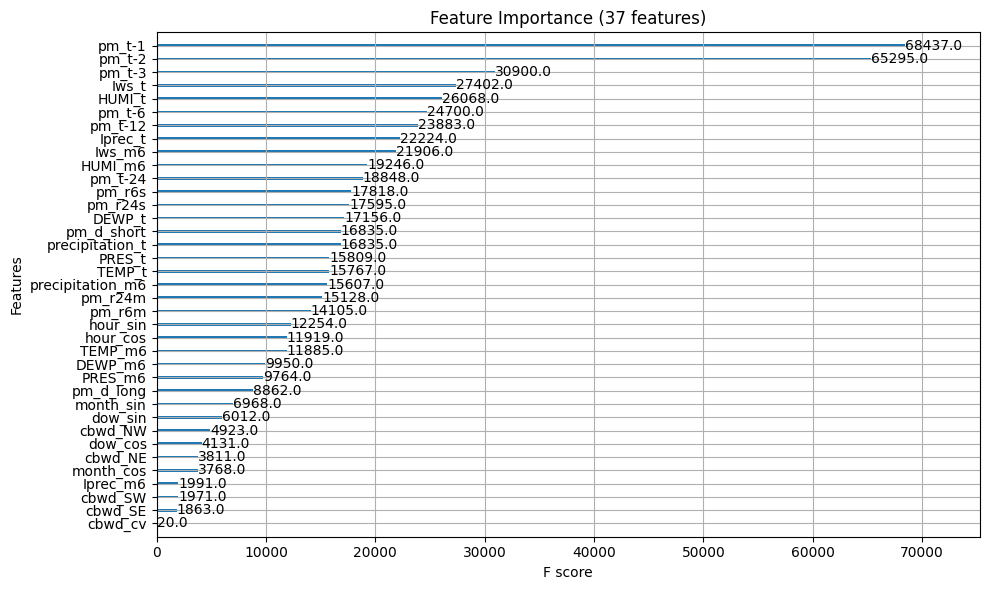

In [ ]:
# ============================================================
# XGBoost 训练 (DMatrix → xgb.train, 官方原生 API)
# 参考: https://xgboost.readthedocs.io/en/stable/parameter.html
# ============================================================
dtr = xgb.DMatrix(X_tr, label=y_tr, feature_names=FEATURE_NAMES)
dva = xgb.DMatrix(X_va, label=y_va, feature_names=FEATURE_NAMES)
params = {
    'max_depth': 8, 'eta': 0.05, 'objective': 'reg:squarederror',
    'eval_metric': 'rmse', 'tree_method': 'hist',
    'subsample': 0.85, 'colsample_bytree': 0.85,
    'min_child_weight': 3 'gamma': 0.1 'lambda': 0.2 'alpha': 0.1'nthread': 4,
}
bst = xgb.train(params, dtr, num_boost_round=1000,
                evals=[(dtr,'train'), (dva,'eval')],
                early_stopping_rounds=100, verbose_eval=50)
print(f'\n最佳轮次: {bst.best_iteration} | val RMSE (log): {bst.best_score:.4f}')
fig, ax = plt.subplots(figsize=(10, 6))
xgb.plot_importance(bst, max_num_features=N_FEAT, ax=ax)
plt.title(f'Feature Importance ({N_FEAT} features)'); plt.tight_layout(); plt.show()

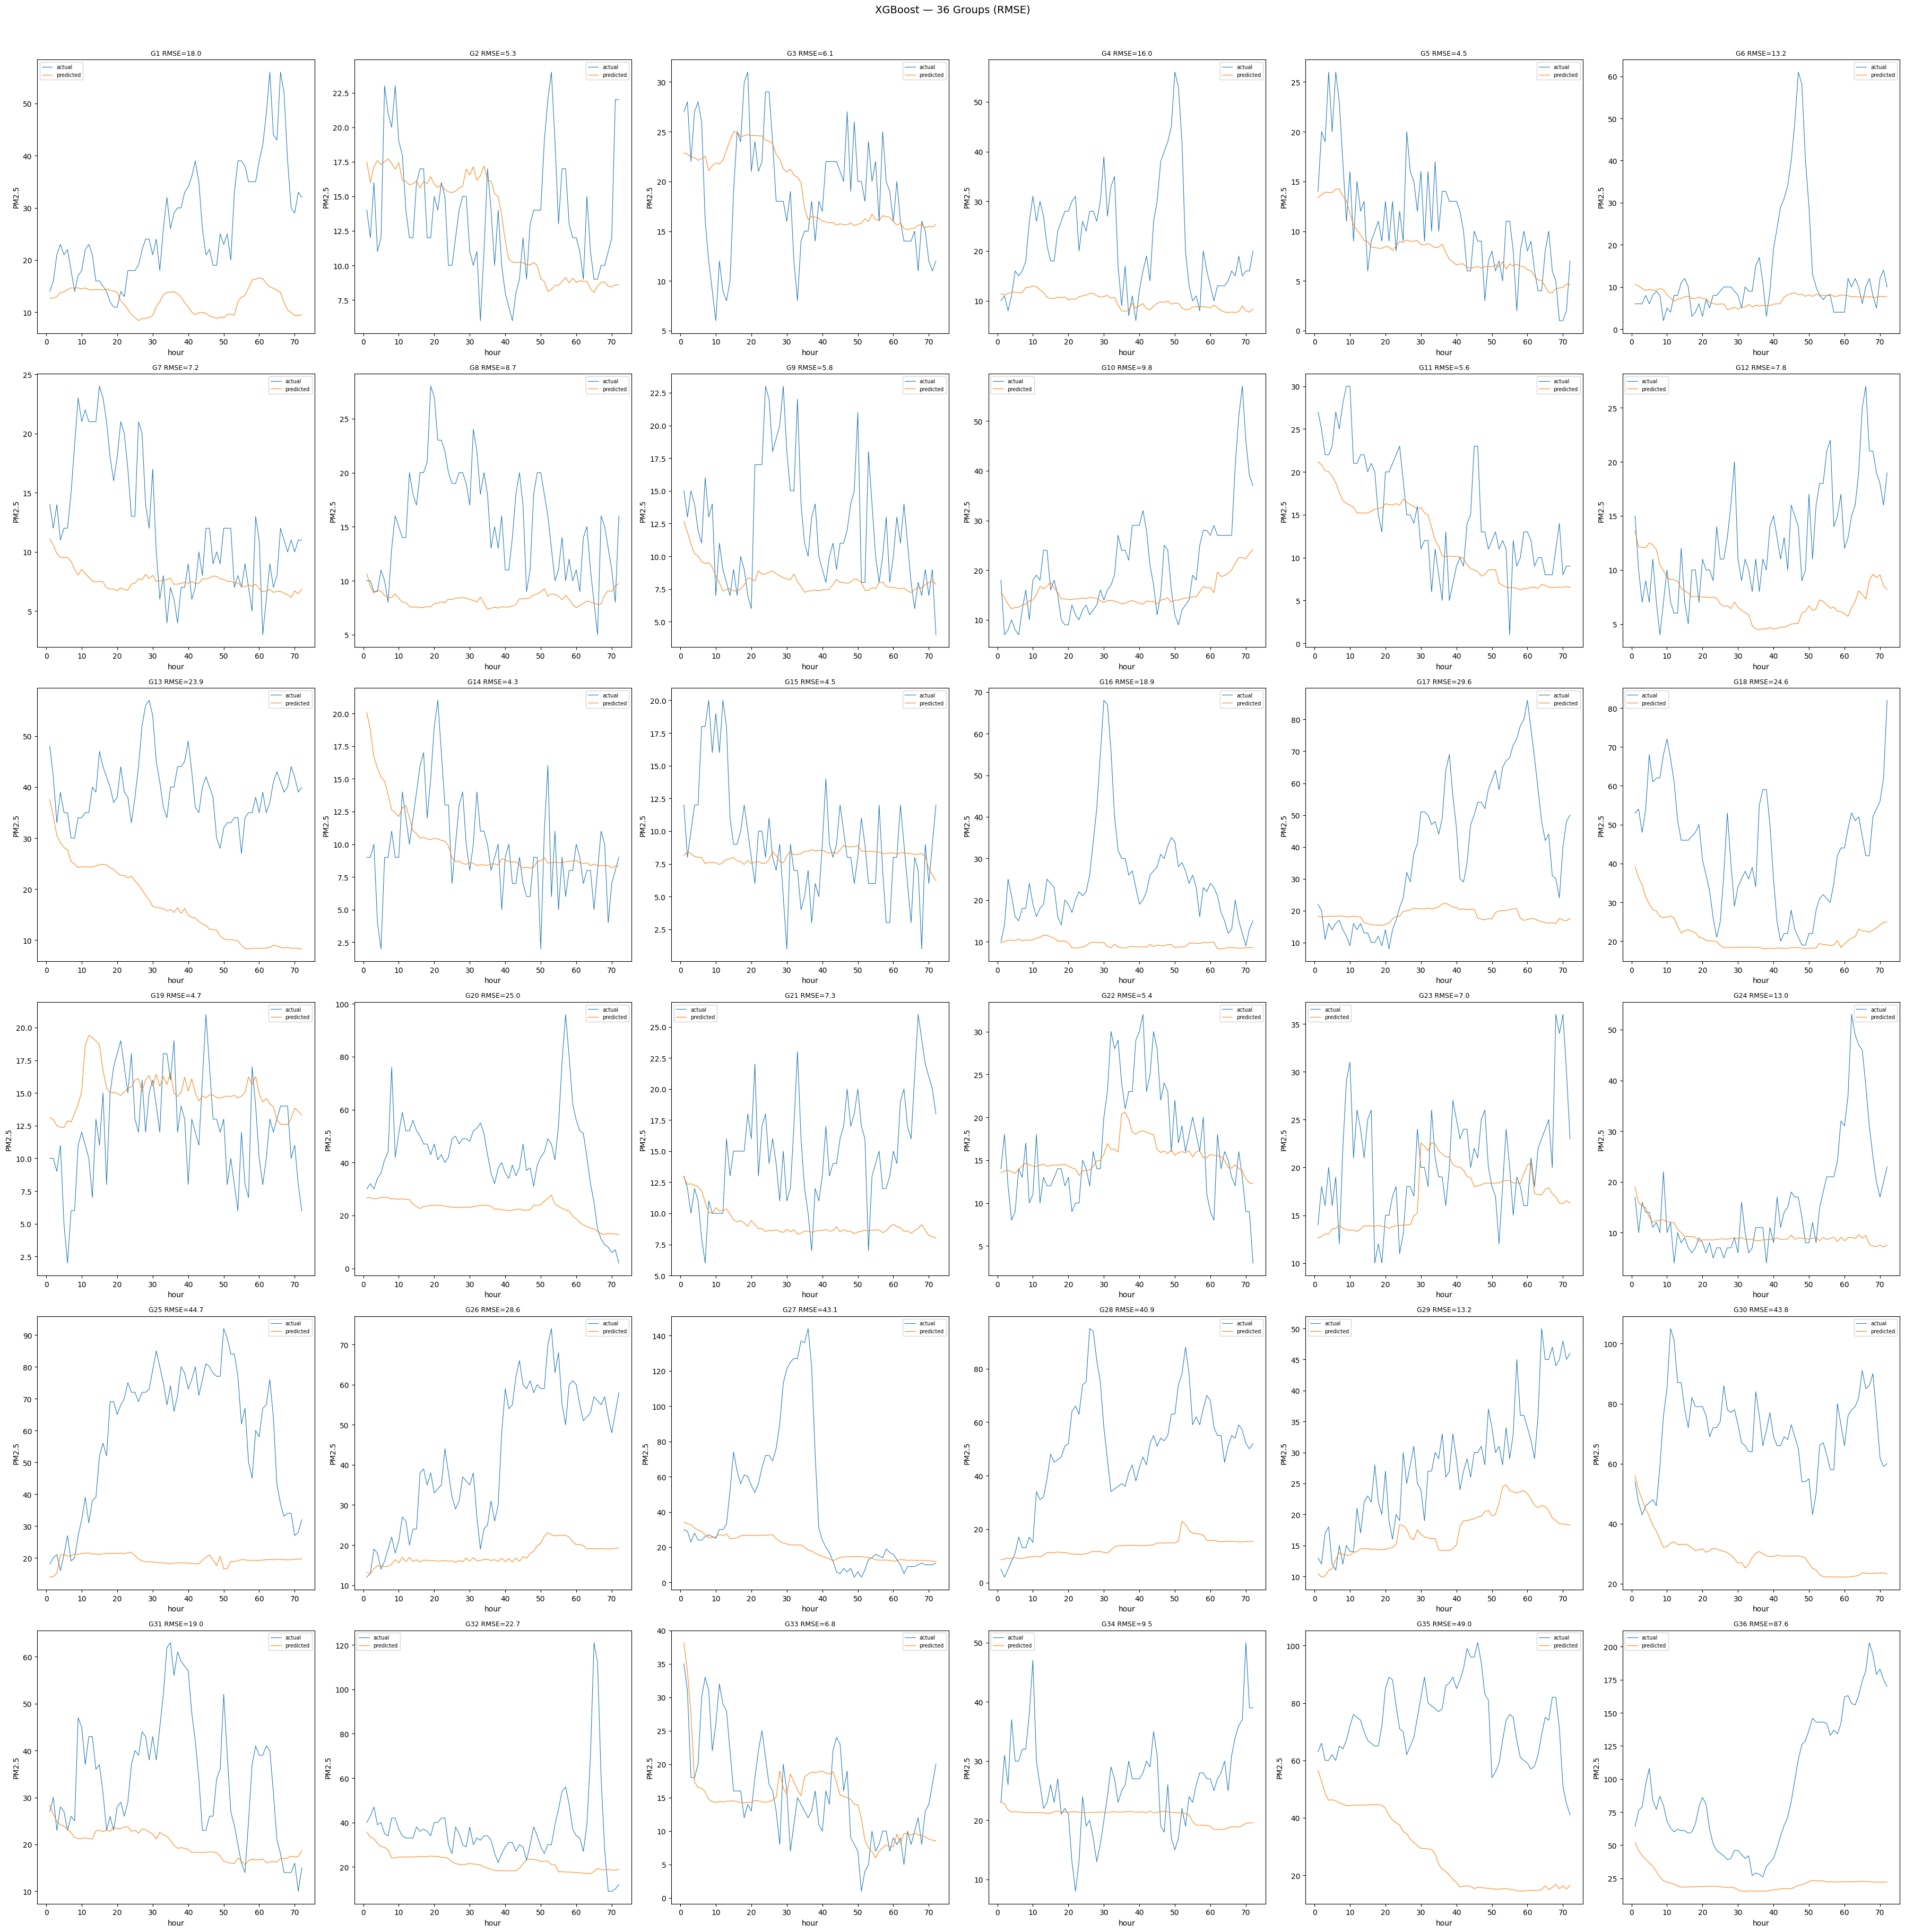


=== 36 组 RMSE 汇总 ===
  G 1: 17.97
  G 2: 5.32
  G 3: 6.09
  G 4: 16.00
  G 5: 4.52
  G 6: 13.18
  G 7: 7.17
  G 8: 8.73
  G 9: 5.80
  G10: 9.78
  G11: 5.56
  G12: 7.78
  G13: 23.92
  G14: 4.32
  G15: 4.49
  G16: 18.92
  G17: 29.58
  G18: 24.63
  G19: 4.72
  G20: 24.96
  G21: 7.35
  G22: 5.44
  G23: 6.95
  G24: 12.96
  G25: 44.75
  G26: 28.62
  G27: 43.08
  G28: 40.87
  G29: 13.19
  G30: 43.79
  G31: 18.99
  G32: 22.71
  G33: 6.83
  G34: 9.53
  G35: 49.04
  G36: 87.59

平均 RMSE = 19.03


In [26]:
# ============================================================
# 36 组评估: 每组 24h 上下文 + 72h 递归预测, RMSE (ug/m3)
# 预测在 log 空间, 最终 expm1 还原到原始量纲
# ============================================================
N_GROUPS, N_CTX, N_PRED = 36, 24, 72
STRIDE = (len(df_te) - N_CTX - N_PRED) // (N_GROUPS - 1)
pm_te = df_te['pm_ave'].values  # log 空间
w_te = df_te[WEATHER].values; wm6_te = df_te[WEATHER_M6].values
t_te = df_te[TIME_COLS].values; c_te = df_te[CBWD_COLS].values

rmses = []
fig, axes = plt.subplots(6, 6, figsize=(36, 36)); axes = axes.flatten()
for g in range(N_GROUPS):
    s = g * STRIDE
    pm_ser = np.zeros(N_CTX + N_PRED); pm_ser[:N_CTX] = pm_te[s:s+N_CTX]
    for i in range(N_PRED):
        T = s + N_CTX + i; pos = N_CTX + i
        row = [pm_ser[pos-l] for l in PM_LAGS]
        row.extend(w_te[T]); row.extend(wm6_te[T])
        row.extend(t_te[T]); row.extend(c_te[T])
        r6 = pm_ser[max(0,pos-6):pos]; r24 = pm_ser[max(0,pos-24):pos]
        row += [np.mean(r6), max(np.std(r6,ddof=1) if len(r6)>1 else 0, STD_F6),
                np.mean(r24), max(np.std(r24,ddof=1) if len(r24)>1 else 0, STD_F24),
                pm_ser[pos-1]-pm_ser[pos-3], pm_ser[pos-1]-pm_ser[pos-24]]
        dp = xgb.DMatrix(np.array(row).reshape(1,-1), feature_names=FEATURE_NAMES)
        pm_ser[pos] = np.clip(bst.predict(dp, iteration_range=(0, bst.best_iteration+1))[0], CLIP_LO, CLIP_HI)
    preds  = np.expm1(pm_ser[N_CTX:])
    actual = np.expm1(pm_te[s+N_CTX:s+N_CTX+N_PRED])
    rmse = np.sqrt(((preds - actual) ** 2).mean())
    rmses.append(rmse)
    ax = axes[g]; h = np.arange(1, N_PRED+1)
    ax.plot(h, actual, lw=0.8, label='actual')
    ax.plot(h, preds, lw=0.8, label='predicted')
    ax.set_title(f'G{g+1} RMSE={rmse:.1f}', fontsize=9)
    ax.legend(fontsize=7); ax.set_xlabel('hour'); ax.set_ylabel('PM2.5')
plt.suptitle(f'XGBoost — {N_GROUPS} Groups (RMSE)', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()
print(f'\n=== {N_GROUPS} 组 RMSE 汇总 ===')
for g, r in enumerate(rmses): print(f'  G{g+1:2d}: {r:.2f}')
print(f'\n平均 RMSE = {np.mean(rmses):.2f}')